In [1]:
import os

os.chdir("../")

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Ellipse, Patch
from scipy.io import loadmat
from sklearn.metrics import adjusted_rand_score

from src._config import IMG_DIR, MAX_BELIEF_COHORT_A, MAX_BELIEF_COHORT_B, RANDOM_SEED
from src.cluster2 import CLUSTERERS, fit_predict, fuzzy_fit_predict, ablate_k, ablate_X, ablate_solver
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statannotations.Annotator import Annotator

from src.preprocessing import collect_metrics, load_behavioral_features, sample_behavioral_features

FIG2_DIR = Path(IMG_DIR) / "fig2"
os.makedirs(FIG2_DIR, exist_ok=True)

## Load data

### Cohort A

In [3]:
# Load raw data
coefs = pd.read_csv("data/cohort_a/coefficients.csv", index_col=0)
print("VBA coefficients (single-point estimate):")
print(coefs.head())
aggro = pd.read_excel("data/cohort_a/aggroPerformance.xlsx", index_col="Subject")
print("Performance:")
print(aggro.head())
beliefs = pd.read_excel("data/cohort_a/beliefs.xlsx", index_col="ID")
if sorted(beliefs.columns) != ["opponent1", "opponent2"]:
    beliefs.rename(columns={k: k[4:] + k[0] for k in beliefs.columns}, inplace=True)
beliefs.drop("opponent3", axis=1, errors="ignore", inplace=True)
print("Opponent beliefs:")
print(beliefs.head())

VBA coefficients (single-point estimate):
           Kr1       Krc        Kp       Kwc
Row                                         
P035  1.322705  2.272587  0.887749 -0.105633
P036  0.409220 -1.830927  0.856839  1.624471
P039  2.147883 -1.102114 -2.232816  0.309552
P041 -0.704294 -0.983443 -2.826260  0.500905
P042 -0.793372  0.147495 -0.700385  1.134931
Performance:
         shock_M_ 1  shock_M_ 2  shock_M_ 3  shock_M_ 4  shock_M_ 5  \
Subject                                                               
P035              0           0           0           1           1   
P036              1           1           1           1           1   
P039              0           0           0           0           0   
P041              0           0           0           0           0   
P042              0           0           1           0           1   

         shock_M_ 6  shock_M_ 7  shock_M_ 8  shock_M_ 9  shock_M_10  ...  \
Subject                                                 

In [4]:
vba_metrics = pd.read_csv("data/cohort_a/fit_metrics.csv", index_col=0)
vba_preds = pd.read_csv("data/cohort_a/predictions.csv", header=None)
vba_actual = pd.read_csv("data/cohort_a/decisions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")

vba_preds.index = ids["subject"]
vba_actual.index = ids["subject"]

all_metrics = collect_metrics(vba_metrics, vba_preds, vba_actual)

all_metrics.head()

,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier
Row,,,,,,
P035,0.151694,0.833333,0.500000,-3476.178261,0.876000,0.115001
P036,0.202331,0.757031,0.708008,-5471.351308,0.791667,0.187659
P039,0.322571,0.869141,0.513409,-3068.142219,0.961538,0.074803
P041,0.000000,1.000000,NaN,-782.871692,0.500000,0.001554
P042,0.080530,0.713281,0.489435,-4958.373115,0.715909,0.179249


In [5]:
bma_a = load_behavioral_features(
    coefs,
    all_metrics,
    aggro,
    beliefs,
)

print(bma_a.shape)

bma_a.head()

(114, 15)


,Kr1,Krc,Kp,Kwc,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier,shock_opp1,shock_opp2,first_shock,belief_opp1,belief_opp2
Row,,,,,,,,,,,,,,,
P035,1.322705,2.272587,0.887749,-0.105633,0.151694,0.833333,0.500000,-3476.178261,0.876000,0.115001,10.0,15.0,3.0,5.000000,3.000000
P036,0.409220,-1.830927,0.856839,1.624471,0.202331,0.757031,0.708008,-5471.351308,0.791667,0.187659,8.0,10.0,0.0,4.333963,4.698228
P039,2.147883,-1.102114,-2.232816,0.309552,0.322571,0.869141,0.513409,-3068.142219,0.961538,0.074803,1.0,3.0,11.0,7.000000,5.000000
P042,-0.793372,0.147495,-0.700385,1.134931,0.080530,0.713281,0.489435,-4958.373115,0.715909,0.179249,2.0,6.0,2.0,4.000000,5.000000
P043,-0.704294,-0.983443,-2.826260,0.500905,0.000000,1.000000,0.357809,-782.871692,0.500000,0.001554,0.0,0.0,30.0,5.000000,0.000000


### Cohort B

In [6]:
coefs_b = pd.read_csv("data/cohort_b/coefficients.csv", index_col=0)
print("VBA coefficients (single-point estimate; cohort B):")
print(coefs_b.head())
aggro_b = pd.read_excel("data/cohort_b/aggroPerformance.xlsx", index_col="Subject")
print("Performance (cohort B):")
print(aggro_b.head())
beliefs_b = pd.read_excel("data/cohort_b/beliefs.xlsx", index_col="ID")
beliefs_b = beliefs_b * (MAX_BELIEF_COHORT_A / MAX_BELIEF_COHORT_B)
print("Opponent beliefs (cohort B):")
print(f"Shape: {beliefs_b.shape}")
print(beliefs_b.head())

VBA coefficients (single-point estimate; cohort B):
            Kr1       Krc        Kp       Kwc
Row                                          
BF042 -0.566837  1.311892 -1.126599 -0.358198
BF055  0.446400 -0.963399  0.389564  0.147150
BF060  0.846845  1.040426  2.024652  0.614868
BF065 -1.006059 -1.155588  0.547222  0.203727
BF069  1.413274  1.507436 -0.658041  0.221011
Performance (cohort B):
         shock_M_ 1  shock_M_ 2  shock_M_ 3  shock_M_ 4  shock_M_ 5  \
Subject                                                               
BF042             0           0           0           0           0   
BF055             1           1           1           1           1   
BF065             1           1           0           1           1   
BF069             1           1           0           0           0   
BF087             0           0           0           0           0   

         shock_M_ 6  shock_M_ 7  shock_M_ 8  shock_M_ 9  shock_M_10  ...  \
Subject                     

In [7]:
vba_metrics_b = pd.read_csv("data/cohort_b/fit_metrics.csv", index_col=0)
vba_preds_b = pd.read_csv("data/cohort_b/predictions.csv", header=None)
vba_actual_b = pd.read_csv("data/cohort_b/decisions.csv", header=None)
ids_b = pd.read_csv("data/cohort_b/subject_ids.csv")

vba_preds_b.index = ids_b["subject"]
vba_actual_b.index = ids_b["subject"]

all_metrics_b = collect_metrics(vba_metrics_b, vba_preds_b, vba_actual_b)
print(all_metrics_b.shape)
all_metrics_b.head()

(42, 6)


,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier
Row,,,,,,
BF042,0.077620,0.740365,0.513184,-5200.962486,0.664773,0.179840
BF055,0.042331,0.603365,0.544792,-5332.044788,0.675758,0.233353
BF060,0.067995,0.928571,0.500000,-2226.323896,0.961538,0.061233
BF065,0.159349,0.666406,0.666406,-5690.286390,0.815556,0.209618
BF069,0.274577,0.720770,0.715569,-4978.783961,0.878571,0.180146


In [8]:
bma_b = load_behavioral_features(coefs_b, all_metrics_b, aggro_b, beliefs_b, remove_outliers=True)

print(bma_b.shape)

bma_b.head()

(37, 15)


,Kr1,Krc,Kp,Kwc,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier,shock_opp1,shock_opp2,first_shock,belief_opp1,belief_opp2
Row,,,,,,,,,,,,,,,
BF042,-0.566837,1.311892,-1.126599,-0.358198,0.077620,0.740365,0.513184,-5200.962486,0.664773,0.179840,4.0,4.0,8.0,6.000000,2.000000
BF055,0.446400,-0.963399,0.389564,0.147150,0.042331,0.603365,0.544792,-5332.044788,0.675758,0.233353,9.0,6.0,0.0,10.000000,10.000000
BF060,0.846845,1.040426,2.024652,0.614868,0.067995,0.928571,0.500000,-2226.323896,0.961538,0.061233,10.0,10.0,30.0,0.426593,5.787803
BF065,-1.006059,-1.155588,0.547222,0.203727,0.159349,0.666406,0.666406,-5690.286390,0.815556,0.209618,10.0,5.0,0.0,8.000000,4.000000
BF069,1.413274,1.507436,-0.658041,0.221011,0.274577,0.720770,0.715569,-4978.783961,0.878571,0.180146,6.0,8.0,0.0,0.000000,0.000000


In [9]:
scaler = StandardScaler()
cols_to_drop = [
    "Brier", "AUC",
    "accuracy", "balanced_accuracy",
    "log_evidence"
]
Xa = bma_a.drop(columns=cols_to_drop)
Xb = bma_b.drop(columns=cols_to_drop)
print(f"{Xa.shape[1]} columns used: {Xa.columns.tolist()}")
Xa_scaled = scaler.fit_transform(Xa)
Xb_scaled = scaler.transform(Xb)

10 columns used: ['Kr1', 'Krc', 'Kp', 'Kwc', 'R2', 'shock_opp1', 'shock_opp2', 'first_shock', 'belief_opp1', 'belief_opp2']


## Panel (a): PCA projection with clusters

In [10]:
# Cluster with single-point estimates
k = 3
resa = fit_predict(X=Xa_scaled, solver="k-means", k=k, random_state=RANDOM_SEED)
resb_labels = resa.clusterer.predict(Xb_scaled)

In [11]:
post_a = loadmat("data/cohort_a/vba_posteriors.mat")
coefs_mu_a = post_a["mu_all"]
coefs_sigma_a = post_a["sigma_all"]

post_b = loadmat("data/cohort_b/vba_posteriors.mat")
coefs_mu_b = post_b["mu_all"]
coefs_sigma_b = post_b["sigma_all"]

n_samples = 1000

coef_cols = coefs.columns

iterator_a = sample_behavioral_features(
    coefs_mu=coefs_mu_a,
    coefs_sigma=coefs_sigma_a,
    metrics=all_metrics.drop(columns=cols_to_drop),
    aggro=aggro,
    beliefs=beliefs,
    n_samples=n_samples,
)

iterator_b = sample_behavioral_features(
    coefs_mu=coefs_mu_b,
    coefs_sigma=coefs_sigma_b,
    metrics=all_metrics_b.drop(columns=cols_to_drop),
    aggro=aggro_b,
    beliefs=beliefs_b,
    n_samples=n_samples,
    remove_outliers=True,
)

# Cluster with posterior samples
# from src.cluster2 import FuzzyClusterResult
# res = np.load("data/processed/mc_consensus_k-means_3.npz", allow_pickle=True)
# res_kmeans3 = FuzzyClusterResult(
#     consensus_a=res["consensus_a"],
#     consensus_b=res["consensus_b"],
#     stability_a=res["stability_a"],
#     stability_b=res["stability_b"],
#     label_counts_a=res["label_counts_a"],
#     label_counts_b=res["label_counts_b"],
#     scaler_means=res["scaler_means"],
#     scaler_scales=res["scaler_scales"],
#     n_samples=n_samples,
# )
res_kmeans3 = fuzzy_fit_predict(
    iterator_a=iterator_a,
    iterator_b=iterator_b,
    solver="k-means",
    k=k,
    random_state=RANDOM_SEED,
    n_a=len(bma_a),
    n_b=len(bma_b),
    ref_labels=resa.labels,
    n_samples=n_samples,
)

np.savez_compressed(
    "data/processed/mc_consensus_k-means_3.npz",
    consensus_a=res_kmeans3.consensus_a,
    consensus_b=res_kmeans3.consensus_b,
    stability_a=res_kmeans3.stability_a,
    stability_b=res_kmeans3.stability_b,
    label_counts_a=res_kmeans3.label_counts_a,
    label_counts_b=res_kmeans3.label_counts_b,
    scaler_means=res_kmeans3.scaler_means,
    scaler_scales=res_kmeans3.scaler_scales,
)

print(f"Stability (cohort A): {res_kmeans3.stability_a:.3f}")
print(f"Stability (cohort B): {res_kmeans3.stability_b:.3f}")
print(
    "ARI (consensus vs deterministic):",
    adjusted_rand_score(resa.labels, res_kmeans3.consensus_a),
)
print("Cohort B ARI:", adjusted_rand_score(resb_labels, res_kmeans3.consensus_b))

100%|██████████| 1000/1000 [01:52<00:00,  8.86it/s]


Stability (cohort A): 0.939
Stability (cohort B): 0.945
ARI (consensus vs deterministic): 0.9003208181726069
Cohort B ARI: 0.740486183487789


In [12]:
label_counts_a = res_kmeans3.label_counts_a
changed = res_kmeans3.consensus_a != resa.labels
print(f"Subjects changed: {changed.sum()}/{len(res_kmeans3.consensus_a)}")
for i in np.where(changed)[0]:
    print(
        f"  {bma_a.index[i]}: {resa.labels[i]} → {res_kmeans3.consensus_a[i]} (modal prob: {label_counts_a[i].max() / n_samples:.2f})"
    )

Subjects changed: 4/114
  P042: 2 → 1 (modal prob: 0.53)
  P143: 2 → 0 (modal prob: 0.51)
  P166: 1 → 0 (modal prob: 0.71)
  P174: 1 → 0 (modal prob: 0.53)


In [57]:
# Assign labels
CLUSTERS = [
    {"label": 2, "name": "Non-aggressive", "annot_xy": (-3, -3.5)},
    {"label": 1, "name": "Proactive", "annot_xy": (2, -3.25)},
    {"label": 0, "name": "Reactive", "annot_xy": (-1.5, 4)},
]

cluster_names = {cl["label"]: cl["name"] for cl in CLUSTERS}

Xa["label"] = res_kmeans3.consensus_a # resa.labels
Xa["Cluster"] = Xa["label"].map(cluster_names)
Xb["label"] = res_kmeans3.consensus_b # resb_labels
Xb["Cluster"] = Xb["label"].map(cluster_names)

In [58]:
# PCA on standardized features
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Xa_pca = pca.fit_transform(Xa_scaled)
Xb_pca = pca.transform(Xb_scaled)
Xa[["PC1", "PC2"]] = Xa_pca
Xb[["PC1", "PC2"]] = Xb_pca

In [59]:
Xa.to_csv("data/processed/behav_Xa.csv")
Xb.to_csv("data/processed/behav_Xb.csv")

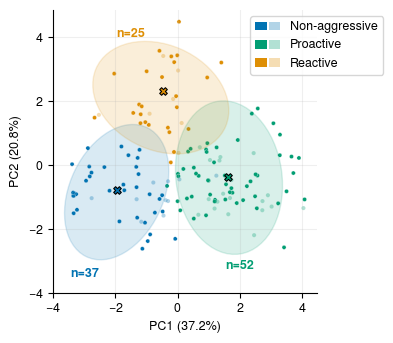

Total variance explained (2D): 58.0%


In [60]:
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse((x.mean(), y.mean()), w, h, angle=angle, **kwargs))

palette = {
    0: "#de8f05",
    2: "#0173b2",
    1: "#029e73",
}

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(4.0, 3.5))

    plot_data = {
        "x": "PC1",
        "y": "PC2",
        "hue": "label",
        "palette": palette,
    }

    sns.scatterplot(**plot_data, data=Xa, ax=ax, legend=False)
    sns.scatterplot(**plot_data, data=Xb, alpha=0.3, ax=ax, legend=False)

    centroids_pca = pca.transform(resa.clusterer.cluster_centers_)

    for cl in CLUSTERS:
        c = cl["label"]
        mask = Xa["label"] == c

        confidence_ellipse(
            Xa.loc[mask, "PC1"].values,
            Xa.loc[mask, "PC2"].values,
            ax,
            n_std=2.0,
            facecolor=palette[c],
            alpha=0.15,
            edgecolor=palette[c],
            linewidth=1,
        )

        ax.annotate(
            f"n={mask.sum()}",
            xy=cl["annot_xy"],
            fontweight="bold",
            ha="center",
            color=palette[c],
        )

        ax.scatter(
            centroids_pca[int(c), 0],
            centroids_pca[int(c), 1],
            marker="X",
            s=30,
            color=palette[c],
            edgecolors="black",
            linewidths=0.8,
            zorder=5,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

    handles = [
        (
            Patch(facecolor=palette[cl["label"]]),
            Patch(facecolor=palette[cl["label"]], alpha=0.3),
        )
        for cl in CLUSTERS
    ]
    ax.legend(
        handles,
        [cl["name"] for cl in CLUSTERS],
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.15)},
        loc="upper center",
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
    )
    ax.grid(alpha=0.2)

    lim = 4
    ticks = np.linspace(-lim, lim, 5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    plt.savefig(FIG2_DIR / "pca_clusters.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "pca_clusters.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Total variance explained (2D): {pca.explained_variance_ratio_.sum():.1%}")

## Panel (b): Radar charts -- per-cluster behavioral profiles

In [61]:
minmax_scaler = MinMaxScaler()

Xa_minmax = minmax_scaler.fit_transform(Xa.drop(["PC1", "PC2", "Cluster", "label"], axis=1))

cluster_means_a = minmax_scaler.transform(
    Xa.drop(["PC1", "PC2", "label"], axis=1).groupby("Cluster").mean()
)

Xb_minmax = minmax_scaler.transform(Xb.drop(["PC1", "PC2", "Cluster", "label"], axis=1))

cluster_means_b = minmax_scaler.transform(
    Xb.drop(["PC1", "PC2", "label"], axis=1).groupby("Cluster").mean()
)

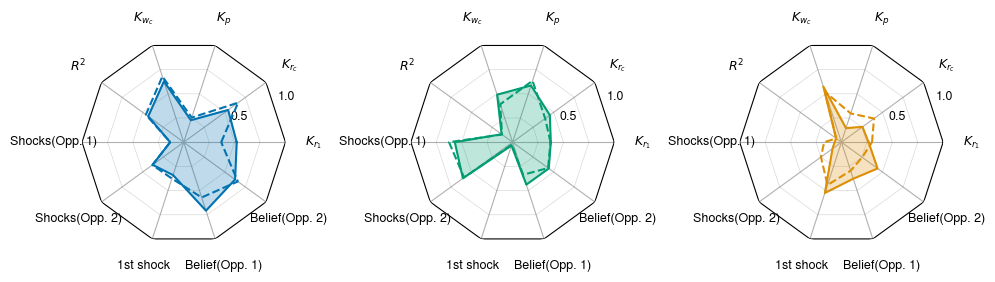

In [64]:
radar_labels = [
    r"$K_{r_1}$", r"$K_{r_c}$", r"$K_p$", r"$K_{w_c}$", r"$R^2$",
    "Shocks(Opp. 1)", "Shocks(Opp. 2)", "1st shock",
    "Belief(Opp. 1)", "Belief(Opp. 2)"
]

n_features = Xa_scaled.shape[1]
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), subplot_kw=dict(polar=True))

    for ax, cluster_id in zip(axes, [2, 1, 0]):
        values = cluster_means_a[cluster_id].tolist()
        values += values[:1]

        ax.fill(angles, values, alpha=0.25, color=palette[cluster_id], zorder=10)
        ax.plot(angles, values, color=palette[cluster_id], linewidth=1.5)

        values_b = cluster_means_b[cluster_id].tolist()
        values_b += values_b[:1]
        ax.plot(angles, values_b, color=palette[cluster_id], linewidth=1.5, linestyle="--")

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_labels)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["", "0.5", "", "1.0"])
        ax.yaxis.grid(False)
        ax.spines["polar"].set_visible(False)
        for r in [0.25, 0.5, 0.75, 1.0]:
            style = (
                {"color": "black", "linewidth": 0.8}
                if r == 1.0
                else {"color": "gray", "linewidth": 0.5, "alpha": 0.3}
            )
            ax.plot(angles, [r] * len(angles), **style)
        ax.tick_params(axis="x", pad=10)
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "radar_charts.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "radar_charts.png", dpi=300, bbox_inches="tight")
    plt.show()

## Panel (c): Per-cluster shocks by opponent

In [ ]:
# Melt shock_opp1 and shock_opp2 into long format
Xa.index.name = "subject"
shock_long = (
    Xa[["shock_opp1", "shock_opp2", "label", "Cluster"]]
    .reset_index()
    .melt(
        id_vars=["subject", "label", "Cluster"],
        value_vars=["shock_opp1", "shock_opp2"],
        var_name="opponent",
        value_name="shocks",
    )
)
shock_long["opponent"] = shock_long["opponent"].map(
    {"shock_opp1": "Opponent 1", "shock_opp2": "Opponent 2"}
)

os.makedirs("data/processed", exist_ok=True)

shock_long.to_csv("data/processed/shock_long.csv", index=False)

shock_long.head()

,subject,label,Cluster,opponent,shocks
0,P035,1,Proactive,Opponent 1,10.0
1,P036,1,Proactive,Opponent 1,8.0
2,P039,0,Reactive,Opponent 1,1.0
3,P042,1,Proactive,Opponent 1,2.0
4,P043,2,Non-aggressive,Opponent 1,0.0


In [65]:
shock_long_posterior = pd.read_csv("data/brms/shocks/posterior_epred.csv").drop(
    columns=[".row", ".draw"]
)

print(shock_long_posterior.shape)

print(shock_long_posterior.groupby(["opponent", "Cluster"]).describe())

shock_long_posterior.head()

(48000, 3)
                           shocks                                          \
                            count      mean       std       min       25%   
opponent   Cluster                                                          
Opponent 1 Non-aggressive  8000.0  0.822284  0.173307  0.380014  0.698391   
           Proactive       8000.0  8.717304  0.513791  6.278855  8.384533   
           Reactive        8000.0  1.802980  0.360621  0.766926  1.544299   
Opponent 2 Non-aggressive  8000.0  1.340055  0.249346  0.619119  1.167289   
           Proactive       8000.0  9.354585  0.499315  7.255142  9.031076   
           Reactive        8000.0  5.521051  0.688112  3.192769  5.049348   

                                                          
                                50%       75%        max  
opponent   Cluster                                        
Opponent 1 Non-aggressive  0.806155  0.931373   1.865585  
           Proactive       8.726552  9.060754  10.863287  


,Cluster,opponent,shocks
0,Proactive,Opponent 1,9.197446
1,Proactive,Opponent 1,8.542178
2,Proactive,Opponent 1,8.478643
3,Proactive,Opponent 1,8.761732
4,Proactive,Opponent 1,8.507796


In [ ]:
bf_shocks = pd.read_csv("data/brms/shocks/bayes_factors.csv")

print(bf_shocks)

                       contrast    opponent  estimate  lower.HPD  upper.HPD  \
0  (Non-aggressive) - Proactive  Opponent 1 -3.194914  -3.735500  -2.709065   
1   (Non-aggressive) - Reactive  Opponent 1 -0.859306  -1.469139  -0.251816   
2          Proactive - Reactive  Opponent 1  2.341124   1.812576   2.861915   
3  (Non-aggressive) - Proactive  Opponent 2 -2.845222  -3.310870  -2.335052   
4   (Non-aggressive) - Reactive  Opponent 2 -1.790615  -2.338849  -1.224854   
5          Proactive - Reactive  Opponent 2  1.051924   0.551535   1.505627   

           BF10  excl_zero  
0  1.591641e+10       True  
1  8.597661e+00       True  
2  5.519947e+08       True  
3  1.132176e+11       True  
4  1.794021e+04       True  
5  1.078190e+02       True  


In [ ]:
def parse_contrast(c):
    """'(Non-aggressive) - Proactive' -> ('Non-aggressive', 'Proactive')"""
    parts = c.split(" - ")
    return parts[0].strip("() "), parts[1].strip("() ")


sig = bf_shocks[bf_shocks["excl_zero"]]

sig_contrasts_shocks = {}
for opp in bf_shocks["opponent"].unique():
    opp_sig = sig[sig["opponent"] == opp]
    sig_contrasts_shocks[opp] = []
    for _, row in opp_sig.iterrows():
        c1, c2 = parse_contrast(row["contrast"])
        bf = row["BF10"]
        label = "BF > 100" if bf > 100 else f"BF = {bf:.0f}"
        sig_contrasts_shocks[opp].append((c1, c2, label))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Opponent 2_Non-aggressive vs. Opponent 2_Reactive: BF > 100
Opponent 2_Reactive vs. Opponent 2_Proactive: BF > 100
Opponent 1_Non-aggressive vs. Opponent 1_Reactive: BF = 9
Opponent 1_Reactive vs. Opponent 1_Proactive: BF > 100
Opponent 2_Non-aggressive vs. Opponent 2_Proactive: BF > 100
Opponent 1_Non-aggressive vs. Opponent 1_Proactive: BF > 100


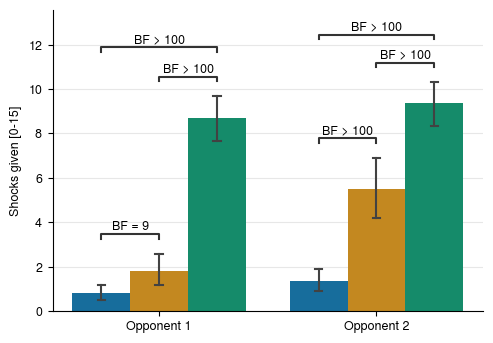

In [ ]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    sns.barplot(
        data=shock_long_posterior,
        x="opponent",
        y="shocks",
        hue="Cluster",
        hue_order=["Non-aggressive", "Reactive", "Proactive"],
        palette=palette,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Shocks given [0-15]")
    # ax.legend(title="")
    ax.legend().remove()
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    pairs = []
    custom_annots = []
    for opp in sig_contrasts_shocks:
        for c1, c2, bf_label in sig_contrasts_shocks[opp]:
            pairs.append(((opp, c1), (opp, c2)))
            custom_annots.append(bf_label)

    if pairs:
        annot = Annotator(
            ax,
            pairs,
            data=shock_long_posterior,
            x="opponent",
            y="shocks",
            hue="Cluster",
            hue_order=["Non-aggressive", "Reactive", "Proactive"],
        )
        annot.set_custom_annotations(custom_annots)
        annot.annotate()

    plt.savefig(FIG2_DIR / "shocks_by_opponent.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "shocks_by_opponent.png", dpi=300, bbox_inches="tight")
    plt.show()

## Panel (d): PSAP concurrent validity

In [ ]:
# Load PSAP data and merge with Bravura clusters
psap = pd.read_excel("data/raw/additional.xlsx")
psap = psap.set_index("Subject")

# Merge with Bravura cluster labels (Xa index = subject IDs)
psap_cluster = psap[["pA", "pB", "pC", "rA", "rB", "rC"]].join(
    Xa[["label", "Cluster"]], how="inner"
)
psap_cluster = psap_cluster.dropna()

psap_dir = psap_cluster.reset_index()
psap_pro = psap_dir[["Subject", "label", "Cluster", "pA", "pB", "pC"]].copy()
psap_pro.columns = ["Subject", "label", "Cluster", "Earn", "Steal", "Protect"]
psap_pro["phase"] = "Proactive"

psap_rea = psap_dir[["Subject", "label", "Cluster", "rA", "rB", "rC"]].copy()
psap_rea.columns = ["Subject", "label", "Cluster", "Earn", "Steal", "Protect"]
psap_rea["phase"] = "Reactive"

# Combine phases
psap_comp = pd.concat([psap_pro, psap_rea], ignore_index=True)

# Replace zeros and ones with noise, then renormalize
rng = np.random.default_rng(RANDOM_SEED)
buttons = ["Earn", "Steal", "Protect"]

for i, row in psap_comp.iterrows():
    vals = row[buttons].values.astype(float)
    # Replace zeros with N(0.01, 0.0025), clipped to (0, min_real_nonzero)
    zero_mask = vals == 0
    ones_mask = vals == 1.0
    n_zeros = zero_mask.sum()
    if n_zeros > 0:
        noise = rng.normal(0.01, 0.0025, size=n_zeros).clip(1e-6, 0.025)
        vals[zero_mask] = noise
    if ones_mask.any():
        vals[ones_mask] = 1.0  # will be adjusted by renormalization
    # Renormalize so row sums to 1
    vals = vals / vals.sum()
    psap_comp.loc[i, buttons] = vals

psap_comp.to_csv("data/processed/psap_ilr.csv", index=False)
psap_comp.head()

,Subject,label,Cluster,Earn,Steal,Protect,phase
0,P035,1,Proactive,0.333333,0.333333,0.333333,Proactive
1,P036,1,Proactive,0.571429,0.142857,0.285714,Proactive
2,P039,0,Reactive,0.200000,0.333333,0.466667,Proactive
3,P042,1,Proactive,0.230769,0.461538,0.307692,Proactive
4,P043,2,Non-aggressive,0.395741,0.010647,0.593612,Proactive


In [ ]:
posterior_psap = pd.read_csv("data/brms/psap/posterior_epred.csv")

posterior_psap.head()

,.row,Cluster,phase,.draw,button,proportion
0,1,Proactive,Proactive,1,Earn,0.559398
1,1,Proactive,Proactive,2,Earn,0.574494
2,1,Proactive,Proactive,3,Earn,0.608081
3,1,Proactive,Proactive,4,Earn,0.609448
4,1,Proactive,Proactive,5,Earn,0.593436


In [ ]:
bf_table = pd.read_csv("data/brms/psap/bayes_factors.csv")
print(bf_table)

        phase   button                    contrast  estimate     lower  \
0   Proactive    Steal  Proactive - Non-aggressive  0.770155  0.179346   
1   Proactive    Steal   Reactive - Non-aggressive  0.241038 -0.458170   
2   Proactive    Steal        Proactive - Reactive  0.529118 -0.106816   
3    Reactive    Steal  Proactive - Non-aggressive  0.978694  0.388515   
4    Reactive    Steal   Reactive - Non-aggressive  0.732949  0.016992   
5    Reactive    Steal        Proactive - Reactive  0.245745 -0.395442   
6   Proactive  Protect  Proactive - Non-aggressive -0.165570 -0.605581   
7   Proactive  Protect   Reactive - Non-aggressive -0.500161 -1.032437   
8   Proactive  Protect        Proactive - Reactive  0.334590 -0.161629   
9    Reactive  Protect  Proactive - Non-aggressive -0.050691 -0.501979   
10   Reactive  Protect   Reactive - Non-aggressive -0.032248 -0.565811   
11   Reactive  Protect        Proactive - Reactive -0.018443 -0.536607   
12  Proactive     Earn  Proactive - No

In [ ]:
def get_bf(phase, button, c1, c2):
    row = bf_table[
        (bf_table["phase"] == phase)
        & (bf_table["button"] == button)
        & (bf_table["contrast"] == f"{c1} - {c2}")
    ]
    return row["BF10"].values[0]


# Significant contrasts per phase
sig = bf_table[bf_table["excl_zero"]]

sig_contrasts = {}
for phase in ["Proactive", "Reactive"]:
    phase_sig = sig[sig["phase"] == phase]
    sig_contrasts[phase] = [
        (
            row["button"],
            row["contrast"].split(" - ")[0],
            row["contrast"].split(" - ")[1],
            "*",
        )
        for _, row in phase_sig.iterrows()
    ]

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Steal_Non-aggressive vs. Steal_Proactive: *
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Steal_Non-aggressive vs. Steal_Reactive: *
Steal_Non-aggressive vs. Steal_Proactive: *


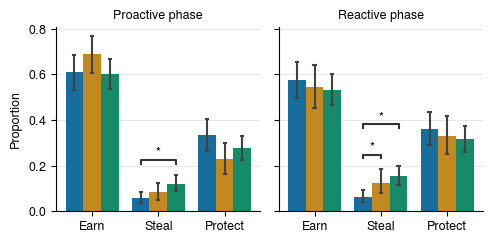

In [ ]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)

    for ax, phase in zip(axes, ["Proactive", "Reactive"]):
        phase_data = posterior_psap[posterior_psap["phase"] == phase]
        sns.barplot(
            data=phase_data,
            x="button",
            y="proportion",
            hue="Cluster",
            hue_order=["Non-aggressive", "Reactive", "Proactive"],
            order=["Earn", "Steal", "Protect"],
            palette=palette,
            errorbar=("pi", 95),
            capsize=0.1,
            ax=ax,
        )
        ax.set_title(f"{phase} phase")
        ax.set_xlabel("")
        ax.set_axisbelow(True)
        ax.grid(alpha=0.3, axis="y", zorder=0)
        ax.get_legend().remove()

        pairs = []
        custom_annots = []
        for button, c1, c2, bf_label in sig_contrasts.get(phase, []):
            pairs.append(((button, c1), (button, c2)))
            custom_annots.append(bf_label)

        if pairs:
            annot = Annotator(
                ax, pairs, data=phase_data,
                x="button", y="proportion", hue="Cluster",
                hue_order=["Non-aggressive", "Reactive", "Proactive"],
                order=["Earn", "Steal", "Protect"],
            )
            annot.set_custom_annotations(custom_annots)
            annot.annotate()

    axes[0].set_ylabel("Proportion")
    # axes[-1].legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(FIG2_DIR / "psap_concurrent.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "psap_concurrent.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: PSAP Dirichlet pp_check

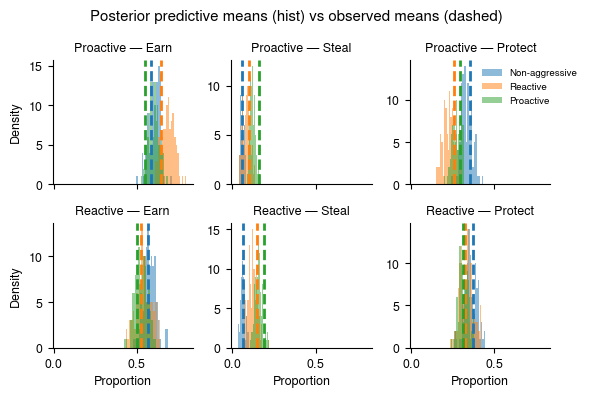

In [ ]:
pred = pd.read_csv("data/brms/psap/posterior_epred.csv")
obs = pd.read_csv("data/processed/psap_ilr.csv")

# Observed means per cell
obs_long = obs.melt(
    id_vars=["Subject", "Cluster", "phase"],
    value_vars=["Earn", "Steal", "Protect"],
    var_name="button",
    value_name="proportion",
)
obs_means = obs_long.groupby(["Cluster", "phase", "button"])["proportion"].mean()

# Posterior predictive: sample 100 draws, compute mean per cell
draws = pred[
    pred[".draw"].isin(
        np.random.default_rng(42).choice(pred[".draw"].unique(), 100, replace=False)
    )
]
pp_means = draws.groupby([".draw", "Cluster", "phase", "button"])["proportion"].mean()

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(2, 3, figsize=(6, 4), sharex=True)
    for j, phase in enumerate(["Proactive", "Reactive"]):
        for k, button in enumerate(["Earn", "Steal", "Protect"]):
            ax = axes[j, k]
            for i, cluster in enumerate(["Non-aggressive", "Reactive", "Proactive"]):
                pp = pp_means.xs(
                    (cluster, phase, button), level=("Cluster", "phase", "button")
                )
                ax.hist(pp.values, bins=20, alpha=0.5, label=cluster)
                ax.axvline(
                    obs_means[(cluster, phase, button)], color=f"C{i}", ls="--", lw=2
                )
            ax.set_title(f"{phase} — {button}")
            if j == 0 and k == 2:
                ax.legend(fontsize=7, bbox_to_anchor=(0.45, 1), loc="upper left")
            if k == 0:
                ax.set_ylabel("Density")
            if j == 1:
                ax.set_xlabel("Proportion")

    fig.suptitle("Posterior predictive means (hist) vs observed means (dashed)")
    fig.tight_layout()
    plt.savefig(FIG2_DIR / "psap_ppc.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "psap_ppc.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: Sensitivity analysis (goodness-of-fit metric)

In [ ]:
def cov_ari(results):
    ari_matrix = pd.DataFrame(
        np.zeros((len(results), len(results))),
        index=results.index,
        columns=results.index,
    )
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            ari = adjusted_rand_score(
                results.iloc[i]["labels"], results.iloc[j]["labels"]
            )
            ari_matrix.iloc[i, j] = ari
            ari_matrix.iloc[j, i] = ari
            ari_matrix.iloc[i, i] = 1.0
    return ari_matrix

In [ ]:
Xa_brier = bma_a.drop(columns=["R2", "AUC"])
Xa_brier_scaled = StandardScaler().fit_transform(Xa_brier)
Xa_auc = bma_a.drop(columns=["Brier", "R2"])
Xa_auc_scaled = StandardScaler().fit_transform(Xa_auc)
Xa_no_metrics = bma_a.drop(columns=["R2", "Brier", "AUC"])
Xa_no_metrics_scaled = StandardScaler().fit_transform(Xa_no_metrics)

Xs = {
    "R2": Xa_scaled,
    "Brier": Xa_brier_scaled,
    "AUC": Xa_auc_scaled,
    "none": Xa_no_metrics_scaled,
}

sens_X = ablate_X(Xs, solver="k-means", k=k, random_state=RANDOM_SEED)
print(
    sens_X.drop(["labels", "sizes", "clusterer"], axis=1)
    .sort_values(by="silhouette", ascending=False)
    .to_markdown()
)

|       |   silhouette |
|:------|-------------:|
| R2    |     0.235527 |
| AUC   |     0.201612 |
| none  |     0.190519 |
| Brier |     0.189802 |


In [ ]:
print(cov_ari(sens_X))

             R2     Brier       AUC      none
R2     1.000000  0.315651  0.580883  0.280398
Brier  0.315651  1.000000  0.320296  0.385598
AUC    0.580883  0.320296  1.000000  0.367525
none   0.280398  0.385598  0.367525  0.000000


## Supplementary: Comparison of clustering algorithms

In [66]:
solvers = list(CLUSTERERS.keys())

all_res = {}

for solver in solvers:
    print(f"Running solver: {solver}")
    iterator_a = sample_behavioral_features(
        coefs_mu=coefs_mu_a,
        coefs_sigma=coefs_sigma_a,
        metrics=all_metrics.drop(columns=cols_to_drop),
        aggro=aggro,
        beliefs=beliefs,
        n_samples=n_samples,
    )

    iterator_b = sample_behavioral_features(
        coefs_mu=coefs_mu_b,
        coefs_sigma=coefs_sigma_b,
        metrics=all_metrics_b.drop(columns=cols_to_drop),
        aggro=aggro_b,
        beliefs=beliefs_b,
        n_samples=n_samples,
        remove_outliers=False,
    )
    if solver == "k-means":
        all_res[solver] = res_kmeans3
    else:
        all_res[solver] = fuzzy_fit_predict(
            iterator_a=iterator_a,
            iterator_b=iterator_b,
            solver=solver,
            k=k,
            random_state=RANDOM_SEED,
            n_a=len(bma_a),
            n_b=len(bma_b),
            ref_labels=resa.labels,
            n_samples=n_samples,
        )

100%|█████████▉| 999/1000 [17:36<00:01,  1.06s/it]


Running solver: k-means
Running solver: k-medoids


100%|█████████▉| 999/1000 [01:44<00:00,  9.61it/s]


Running solver: gmm


100%|██████████| 1000/1000 [02:11<00:00,  7.63it/s]


In [67]:
rows = []
for solver, res in all_res.items():
    rows.append(
        {
            "solver": solver,
            "stability_a": res.stability_a,
            "stability_b": res.stability_b,
            "ARI_with_kmeans": adjusted_rand_score(
                all_res["k-means"].consensus_a, res.consensus_a
            ),
        }
    )
sens_solver = pd.DataFrame(rows).set_index("solver").sort_values(by="stability_a", ascending=False)
print(sens_solver.to_markdown())

| solver    |   stability_a |   stability_b |   ARI_with_kmeans |
|:----------|--------------:|--------------:|------------------:|
| k-means   |      0.938746 |      0.945054 |          1        |
| gmm       |      0.890386 |      0.896081 |          0.637374 |
| k-medoids |      0.726632 |      0.752892 |          0.866646 |


In [68]:
sens_k = ablate_k(
    Xa_scaled, solver="k-means", k_range=range(2, 11), random_state=RANDOM_SEED
)
print(sens_k[["silhouette", "gap", "gap_diff"]].to_markdown())

|    |   silhouette |      gap |   gap_diff |
|---:|-------------:|---------:|-----------:|
|  2 |     0.221769 |  77.7775 |  -14.6019  |
|  3 |     0.23588  | 114.578  |    3.51996 |
|  4 |     0.211815 | 131.946  |   12.2697  |
|  5 |     0.208056 | 140.777  |   25.715   |
|  6 |     0.179328 | 134.784  |   23.1064  |
|  7 |     0.201257 | 131.468  |   14.5529  |
|  8 |     0.189052 | 134.72   |   17.7841  |
|  9 |     0.202641 | 135.016  |   18.1735  |
| 10 |     0.189545 | 133.451  |  nan       |


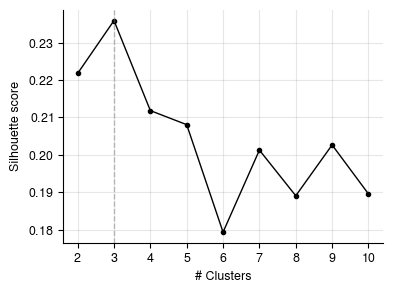

In [ ]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(sens_k.index, sens_k["silhouette"], "o-", color="k")
    ax.axvline(3, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlabel("# Clusters")
    ax.set_ylabel("Silhouette score")
    ax.set_xticks(range(2, 11))
    ax.grid(alpha=0.3)

    plt.savefig(FIG2_DIR / "silhouette_k.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "silhouette_k.png", dpi=300, bbox_inches="tight")
    plt.show()

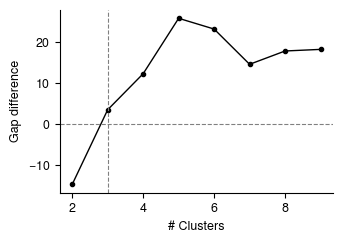

In [71]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(sens_k.index, sens_k["gap_diff"], marker="o", color="k")
    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.axvline(3, ls="--", color="grey", lw=0.8)
    ax.set_xlabel("# Clusters")
    ax.set_ylabel("Gap difference")
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "gap_statistic.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "gap_statistic.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: silhouette plot

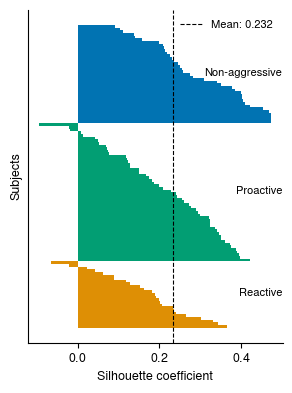

In [72]:
from sklearn.metrics import silhouette_samples

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3, 4))

    sample_sils = silhouette_samples(Xa_scaled, res_kmeans3.consensus_a)
    y_lower = 0

    for c in range(k):
        cluster_sils = np.sort(sample_sils[res_kmeans3.consensus_a == c])[::-1]
        ax.barh(
            range(y_lower, y_lower + len(cluster_sils)),
            cluster_sils,
            height=1.0,
            color=palette[c],
            edgecolor="none",
        )
        ax.text(
            0.5,
            y_lower + len(cluster_sils) / 2,
            cluster_names[c],
            ha="right",
            va="center",
            fontsize=8,
        )
        y_lower += len(cluster_sils)

    ax.axvline(
        sample_sils.mean(),
        color="k",
        linestyle="--",
        linewidth=0.8,
        label=f"Mean: {sample_sils.mean():.3f}",
    )
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Subjects")
    ax.set_yticks([])
    ax.legend(fontsize=8)

    plt.savefig(FIG2_DIR / "silhouette_plot.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "silhouette_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: Bravura-PSAP correlation scatter

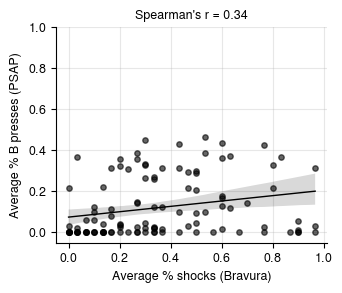

In [ ]:
# Scatter: total Bravura shocks vs PSAP B-presses
psap_scatter = psap_dir[["Subject", "Cluster"]].drop_duplicates()
psap_scatter = psap_scatter.merge(
    psap[["NumShocks", "pB", "rB"]],
    left_on="Subject",
    right_index=True,
)
psap_scatter["B_prop"] = (psap_scatter["pB"] + psap_scatter["rB"]) / 2
psap_scatter = psap_scatter.dropna()
psap_scatter["shock_prop"] = psap_scatter["NumShocks"] / 30
r = psap_scatter["shock_prop"].corr(psap_scatter["B_prop"], method="spearman")

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.regplot(
        data=psap_scatter,
        x="shock_prop",
        y="B_prop",
        scatter_kws={"s": 15, "alpha": 0.6},
        color="k",
        line_kws={"lw": 1},
        ax=ax,
    )
    ax.set_xlabel("Average % shocks (Bravura)")
    ax.set_ylabel("Average % B presses (PSAP)")
    ax.set_ylim(-0.05, 1)
    ax.set_title(f"Spearman's r = {r:.2f}")
    # ax.legend([f"Spearman's $r$ = {r:.2f}"], loc="upper left", frameon=True)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "bravura_psap_scatter.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "bravura_psap_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: MC stability

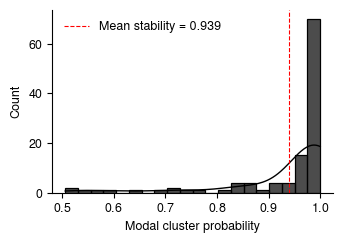

In [ ]:
mc = np.load("data/processed/mc_consensus_k-means_3.npz")
n_mc = int(mc["n_samples"])
modal_prob = mc["label_counts_a"].max(axis=1) / n_mc

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    sns.histplot(modal_prob, bins=20, color="k", alpha=0.7, kde=True, ax=ax)
    ax.axvline(
        modal_prob.mean(),
        color="red",
        linestyle="--",
        linewidth=0.8,
        label=f"Mean stability = {modal_prob.mean():.3f}",
    )
    ax.set_xlabel("Modal cluster probability")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "mc_stability.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "mc_stability.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: PSAP clustering

ARI = 0.024
PSAP             0   1   2
Bravura                   
Non-aggressive   3  14  19
Proactive       19  16  16
Reactive         8  10   7


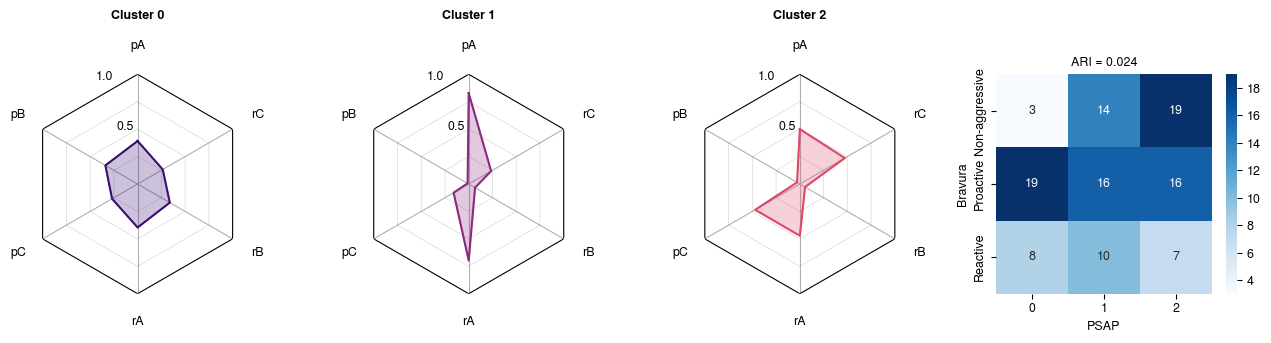

In [ ]:
# PSAP clustering
psap_features = ["pA", "pB", "pC", "rA", "rB", "rC"]
psap_clust = psap_dir[["Subject", "Cluster"] + psap_features].dropna()

X_psap = (
    psap_clust[psap_features]
    .sub(psap_clust[psap_features].mean())
    .div(psap_clust[psap_features].std())
)
res_psap = fit_predict(X_psap.values, solver="k-means", k=3, random_state=RANDOM_SEED)
psap_clust["psap_cluster"] = res_psap.labels

# ARI: Bravura clusters vs PSAP clusters
ari = adjusted_rand_score(psap_clust["Cluster"], psap_clust["psap_cluster"])
print(f"ARI = {ari:.3f}")

# Contingency table
ct = pd.crosstab(
    psap_clust["Cluster"],
    psap_clust["psap_cluster"],
    rownames=["Bravura"],
    colnames=["PSAP"],
)
print(ct)

# PSAP cluster profiles (mean proportions per cluster)
psap_radar_labels = ["pA", "pB", "pC", "rA", "rB", "rC"]
psap_profiles = psap_clust.groupby("psap_cluster")[psap_features].mean()
psap_palette = sns.color_palette("magma", 4)[:-1]  # 3 colors from magma

n_feat = len(psap_features)
angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig = plt.figure(figsize=(13, 3.5))

    for i, cluster_id in enumerate(sorted(psap_profiles.index)):
        ax = fig.add_subplot(1, 4, i + 1, projection="polar")
        ax.set_theta_offset(np.pi / 2)

        values = psap_profiles.loc[cluster_id].tolist()
        values += values[:1]

        ax.fill(angles, values, alpha=0.25, color=psap_palette[cluster_id], zorder=10)
        ax.plot(angles, values, color=psap_palette[cluster_id], linewidth=1.5)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(psap_radar_labels)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["", "0.5", "", "1.0"])
        ax.yaxis.grid(False)
        ax.spines["polar"].set_visible(False)
        for r in [0.25, 0.5, 0.75, 1.0]:
            style = (
                {"color": "black", "linewidth": 0.8}
                if r == 1.0
                else {"color": "gray", "linewidth": 0.5, "alpha": 0.3}
            )
            ax.plot(angles, [r] * len(angles), **style)
        ax.tick_params(axis="x", pad=10)
        ax.set_title(f"Cluster {cluster_id}", pad=15, fontweight="bold")

    ax_ct = fig.add_subplot(1, 4, 4)
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax_ct)
    ax_ct.set_title(f"ARI = {ari:.3f}")

    plt.tight_layout()
    plt.savefig(FIG2_DIR / "psap_clustering.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "psap_clustering.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: questionnaires

In [ ]:
# Curated questionnaires (dropped: PRFd, SIAS, STAI_T, CTQ, IPIP_DOM)
QUESTIONNAIRE_COLS = {
    "RPQ": ["RPQ_R", "RPQ_P", "RPQ_total"],
    "AQ": ["AQ_Physical", "AQ_Verbal", "AQ_Anger", "AQ_Hostility", "AQ_tot"],
    "SRP": ["SRP_IPM", "SRP_CA", "SRP_ELS", "SRP_ASB", "SRP_total"],
    "STAXI-2": [
        "STAXI2_Trait",
        "STAXI2_AXOut",
        "STAXI2_AXIn",
        "STAXI2_AConOut",
        "STAXI2_AConIn",
    ],
    "BES": ["BES_Affective", "BES_Cognitive", "BES_tot"],
    "HEXACO": [
        "HEXACO_HonestyHumility",
        "HEXACO_Emotionality",
        "HEXACO_Extraversion",
        "HEXACO_Agreeableness",
        "HEXACO_Conscientiousness",
        "HEXACO_Openness",
    ],
    "BIS-11": ["BIS11_Attentional", "BIS11_Motor", "BIS11_Nonplanning", "BIS11_tot"],
    "MACHIV": ["MACHIV_Morality", "MACHIV_Views", "MACHIV_Tactics", "MACHIV_tot"],
    "IPAS": ["IPAS_IA", "IPAS_PM", "IPAS_tot"],
    "Other": ["NPI16"],
}
all_q_cols = [c for cols in QUESTIONNAIRE_COLS.values() for c in cols]

quest_raw = pd.read_excel("data/raw/AllDataUnsorted.xlsx", index_col="Subject")

In [ ]:
def run_anova_table(data, between, all_q_cols):
    """One-way ANOVA + FDR-BH across questionnaire scales, with Tukey post-hocs."""
    anova_rows = []
    for col in all_q_cols:
        res = pg.anova(data=data, dv=col, between=between)
        anova_rows.append(
            {
                "scale": col,
                "F": res["F"].iloc[0],
                "ddof1": res["ddof1"].iloc[0],
                "ddof2": res["ddof2"].iloc[0],
                "p": res["p_unc"].iloc[0],
                "eta_sq": res["np2"].iloc[0],
            }
        )

    df_anova = pd.DataFrame(anova_rows)
    df_anova["p_fdr"] = pg.multicomp(df_anova["p"].values, method="fdr_bh")[1]
    df_anova["sig"] = df_anova["p_fdr"] < 0.05

    posthoc_rows = []
    for _, row in df_anova[df_anova["sig"]].iterrows():
        gh = pg.pairwise_tukey(data=data, dv=row["scale"], between=between)
        for _, ph in gh.iterrows():
            posthoc_rows.append(
                {
                    "scale": row["scale"],
                    "A": ph["A"],
                    "B": ph["B"],
                    "diff": ph["diff"],
                    "p_tukey": ph["p_tukey"],
                    "hedges_g": ph["hedges"],
                }
            )

    df_posthoc = pd.DataFrame(posthoc_rows) if posthoc_rows else None
    return df_anova.sort_values("p_fdr"), df_posthoc

In [ ]:
# --- Bravura clusters ---
quest_bravura = Xa[["Cluster"]].join(quest_raw[all_q_cols], how="left")
df_anova_bravura, df_posthoc_bravura = run_anova_table(
    quest_bravura, "Cluster", all_q_cols
)

In [ ]:
# --- PSAP clusters ---
quest_psap = psap_clust[["Subject", "psap_cluster"]].merge(
    quest_raw[all_q_cols], left_on="Subject", right_index=True, how="left",
)
quest_psap["psap_cluster"] = quest_psap["psap_cluster"].astype(int).astype(str)
df_anova_psap, df_posthoc_psap = run_anova_table(quest_psap, "psap_cluster", all_q_cols)

In [ ]:
# --- Display ---
print("=== Bravura clusters ===")
print(f"Significant after FDR: {df_anova_bravura['sig'].sum()}")
print(df_anova_bravura.to_markdown(index=False))
if df_posthoc_bravura is not None:
    print("\nPost-hoc (Tukey HSD):")
    print(df_posthoc_bravura.to_markdown(index=False))

print("\n=== PSAP clusters ===")
print(f"Significant after FDR: {df_anova_psap['sig'].sum()}")
print(df_anova_psap.to_markdown(index=False))
if df_posthoc_psap is not None:
    print("\nPost-hoc (Tukey HSD):")
    print(df_posthoc_psap.to_markdown(index=False))

=== Bravura clusters ===
Significant after FDR: 1
| scale                    |        F |   ddof1 |   ddof2 |           p |     eta_sq |    p_fdr | sig   |
|:-------------------------|---------:|--------:|--------:|------------:|-----------:|---------:|:------|
| HEXACO_HonestyHumility   | 8.18342  |       2 |     111 | 0.000483948 | 0.128502   | 0.018874 | True  |
| STAXI2_AConIn            | 5.16242  |       2 |     111 | 0.0071815   | 0.0851008  | 0.140039 | False |
| BIS11_Nonplanning        | 4.01581  |       2 |     111 | 0.0207093   | 0.0674747  | 0.269221 | False |
| SRP_total                | 3.00453  |       2 |     111 | 0.0536096   | 0.0513556  | 0.298682 | False |
| STAXI2_Trait             | 3.21807  |       2 |     111 | 0.0437952   | 0.0548055  | 0.298682 | False |
| NPI16                    | 3.06537  |       2 |     111 | 0.0506048   | 0.052341   | 0.298682 | False |
| IPAS_PM                  | 3.09445  |       2 |     111 | 0.0492296   | 0.0528113  | 0.298682 | Fals

## Supplementary: latency

In [73]:
# Export shock latency data (trials where shock was given)
shock_cols = sorted(
    [c for c in aggro.columns if c.startswith("shock")],
    key=lambda c: int(c.strip().split("_")[-1]),
)
lat_cols = sorted(
    [c for c in aggro.columns if c.startswith("latency")],
    key=lambda c: int(c.strip().split("_")[-1]),
)

shock_latencies = []
for subj in Xa.index:
    for i, (sc, lc) in enumerate(zip(shock_cols, lat_cols)):
        if aggro.loc[subj, sc] == 1:
            lat = aggro.loc[subj, lc]
            if pd.notna(lat) and lat > 0:
                shock_latencies.append(
                    {
                        "subject": subj,
                        "trial": i + 1,
                        "opponent": 1 if i < 15 else 2,
                        "latency": lat,
                        "Cluster": Xa.loc[subj, "Cluster"],
                    }
                )

df_latency = pd.DataFrame(shock_latencies)
df_latency.to_csv("data/processed/shock_latency_long.csv", index=False)
print(f"Saved {len(df_latency)} shock events")
print(df_latency.groupby("Cluster")["latency"].describe().round(3))

Saved 1203 shock events
                count   mean    std    min    25%    50%    75%    max
Cluster                                                               
Non-aggressive   97.0  0.877  0.441  0.052  0.530  0.777  1.138  1.948
Proactive       914.0  0.778  0.367  0.016  0.511  0.687  0.974  1.981
Reactive        192.0  0.730  0.360  0.238  0.449  0.646  0.962  1.812


   opponent                      contrast      BF10  excl_zero
0         1  (Non-aggressive) - Proactive  0.316529      False
1         1   (Non-aggressive) - Reactive  0.603565      False
2         1          Proactive - Reactive  0.311913      False
3         2  (Non-aggressive) - Proactive  0.677694      False
4         2   (Non-aggressive) - Reactive  0.632417      False
5         2          Proactive - Reactive  0.118649      False


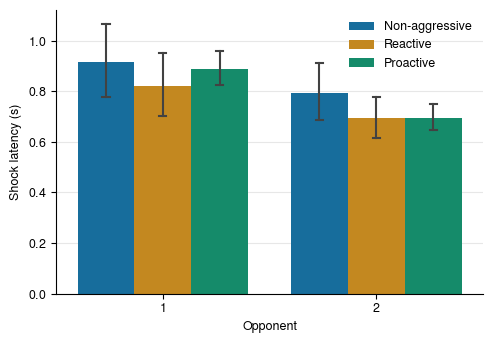

In [75]:
# Shock latency by cluster — posterior predicted means
latency_posterior = pd.read_csv("data/brms/latency/posterior_epred.csv").drop(
    columns=[".row", ".draw"], errors="ignore"
)
bf_latency = pd.read_csv("data/brms/latency/bayes_factors.csv")

print(bf_latency[["opponent", "contrast", "BF10", "excl_zero"]])

cluster_hue_order = ["Non-aggressive", "Reactive", "Proactive"]

cluster_colors = {cl["name"]: palette[cl["label"]] for cl in CLUSTERS}

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    sns.barplot(
        data=latency_posterior,
        x="opponent",
        y="latency",
        hue="Cluster",
        hue_order=cluster_hue_order,
        palette=cluster_colors,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )

    ax.set_xlabel("Opponent")
    ax.set_ylabel("Shock latency (s)")
    ax.legend(title="", frameon=False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    fig.tight_layout()
    fig.savefig(FIG2_DIR / "shock_latency.pdf", bbox_inches="tight")
    fig.savefig(FIG2_DIR / "shock_latency.png", dpi=300, bbox_inches="tight")
    plt.show()

## Supplementary: trial-by-trial P(shock) by cluster

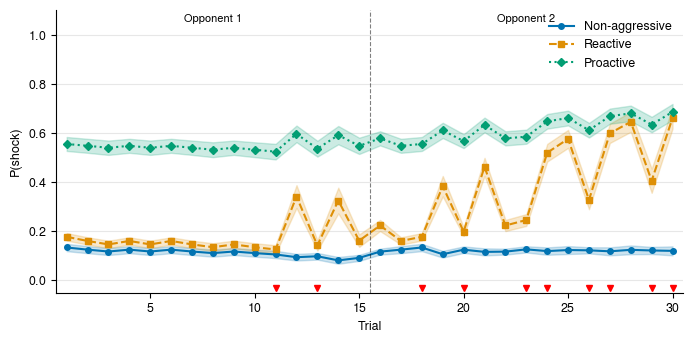

In [76]:
# Supplementary: Trial-by-trial P(shock) by cluster
pred = pd.read_csv("data/cohort_a/predictions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")
pred.index = ids["subject"]

# Filter to clustered subjects
pred_cluster = pred.loc[Xa.index]
pred_cluster["Cluster"] = Xa["Cluster"].values

# Mean ± SEM per cluster per trial
cluster_means = pred_cluster.groupby("Cluster").mean()
cluster_sems = pred_cluster.groupby("Cluster").sem()

# Opponent shock schedule
script = pd.read_excel("data/shared/AggressionScript.xlsx", index_col="Session")
shocked = script.loc["Shocked"].values.astype(int)

cluster_hue_order = ["Non-aggressive", "Reactive", "Proactive"]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(7, 3.5))

    x = np.arange(1, 31)
    markers = ["o", "s", "D"]
    linestyles = ["-", "--", ":"]

    for i, c in enumerate(cluster_hue_order):
        mean = cluster_means.loc[c].values
        sem = cluster_sems.loc[c].values
        color = cluster_colors[c]
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)
        ax.plot(
            x,
            mean,
            color=color,
            marker=markers[i],
            linestyle=linestyles[i],
            label=c,
            markersize=4,
            linewidth=1.5,
        )

    # Mark opponent shocks
    for t in range(30):
        if shocked[t]:
            ax.plot(t + 1, -0.03, marker="v", color="red", markersize=4, clip_on=False)

    ax.axvline(x=15.5, color="k", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.text(8, 1.05, "Opponent 1", ha="center", fontsize=8)
    ax.text(23, 1.05, "Opponent 2", ha="center", fontsize=8)

    ax.set_xlabel("Trial")
    ax.set_ylabel("P(shock)")
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlim(0.5, 30.5)
    ax.legend(title="", frameon=False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    fig.tight_layout()
    fig.savefig(FIG2_DIR / "trial_pshock_by_cluster.pdf", bbox_inches="tight")
    fig.savefig(FIG2_DIR / "trial_pshock_by_cluster.png", dpi=300, bbox_inches="tight")
    plt.show()